# 🧠 Token Embeddings & Positional Embeddings
### A Complete Beginner-to-Intermediate Guide

---

> **What this notebook covers:**
> 1. What is Tokenization? (splitting text into pieces)
> 2. Building a Vocabulary (giving each piece a number)
> 3. Token Embeddings (turning numbers into meaningful vectors)
> 4. Positional Embeddings (telling the model *where* each token is)
> 5. Final Input Embeddings (combining both for a real LLM)

---

### 🤔 Why Do We Need Any Of This?

Computers only understand **numbers**, not text.  
A language model like GPT needs to:
1. Split text into small pieces called **tokens**
2. Convert each token to a unique **integer ID**
3. Map each integer to a rich **vector** (embedding) that captures meaning
4. Add **positional information** so the model knows word order

This pipeline is called **text → tokens → IDs → embeddings**, and it is the very first step inside every modern LLM.

```
"Hello world"  →  ['Hello', 'world']  →  [15496, 995]  →  [[0.3, -0.1, ...], [0.9, 1.5, ...]]
    TEXT              TOKENS               TOKEN IDs           TOKEN EMBEDDINGS
```

---
## 📦 Part 1 — Tokenization: Splitting Text Into Tokens

### What is a Token?

A **token** is the smallest unit of text that an LLM processes.  
Tokens are usually:
- A whole word: `"hello"` → `hello`
- A sub-word: `"unhappiness"` → `un`, `happiness`
- A punctuation mark: `","` or `"."`
- A special symbol: `<|endoftext|>`

> **Why not just use full words?**  
> Because new or rare words (e.g. `"Akwirw"`) would be *unknown*. Sub-word tokenization handles any word by breaking it into known pieces.

### Step 1a — Simple Whitespace Tokenization

In [35]:
import re

# --- The simplest possible tokenizer: split on spaces ---
text = "Hello, world. This is a test."

# Split only on whitespace
tokens_basic = text.split()
print("Split on whitespace:")
print(tokens_basic)

# Problem: commas and periods are glued to words!
# 'Hello,' and 'Hello' would be treated as DIFFERENT tokens

Split on whitespace:
['Hello,', 'world.', 'This', 'is', 'a', 'test.']


### Step 1b — Better: Split on Whitespace AND Punctuation

We use a **regular expression** to split on spaces *and* keep punctuation as separate tokens.

In [36]:
# Split on whitespace (\s) and common punctuation ([,.])
# The parentheses () in the regex KEEP the delimiters in the result
result = re.split(r'([,.]|\s)', text)

print("After split (includes empty strings and spaces):")
print(result)

# Clean: strip whitespace from each piece and remove empty strings
result = [item.strip() for item in result if item.strip()]

print("\nCleaned tokens:")
print(result)

After split (includes empty strings and spaces):
['Hello', ',', '', ' ', 'world', '.', '', ' ', 'This', ' ', 'is', ' ', 'a', ' ', 'test', '.', '']

Cleaned tokens:
['Hello', ',', 'world', '.', 'This', 'is', 'a', 'test', '.']


### Step 1c — Even Better: Handle All Punctuation

Real text has `?`, `!`, `"`, `--` and more. Let's handle them all:

In [37]:
# A more complete regex pattern for punctuation
# It handles: , . : ; ? _ ! " ( ) ' -- and whitespace
text2 = "Hello, world. Is this-- a test? Yes!"

result2 = re.split(r'([,.:;?_!"()\']|--|\s)', text2)
result2 = [item.strip() for item in result2 if item.strip()]

print("Full punctuation-aware tokens:")
print(result2)

print(f"\nNumber of tokens: {len(result2)}")

Full punctuation-aware tokens:
['Hello', ',', 'world', '.', 'Is', 'this', '--', 'a', 'test', '?', 'Yes', '!']

Number of tokens: 12


---
## 📖 Part 2 — Building a Vocabulary & Assigning Token IDs

### What is a Vocabulary?

A **vocabulary** is a dictionary that maps every unique token to a unique integer:

```
vocab = {
    '!'     : 0,
    '"'     : 1,
    'Hello' : 2,
    'world' : 3,
    ....
}
```

The model never sees the word `"Hello"` — it only sees the integer `2`.  
The vocabulary maps text ↔ numbers in both directions.

### Step 2a — Build the Vocabulary from Real Text

In [38]:
# Sample corpus (a few sentences standing in for a real text file)
corpus = """
I had always thought Jack Gisburn rather a cheap genius -- though a good fellow enough.
It was no great surprise to me to hear that he had married a rich woman.
She was the last he painted, you know -- Mrs. Gisburn said with pardonable pride.
In the sunlit terraces of the palace, the verdict was delivered.
"""

# Tokenize the corpus
preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', corpus)
preprocessed = [item.strip() for item in preprocessed if item.strip()]

print(f"Total tokens in corpus: {len(preprocessed)}")
print(f"Sample tokens: {preprocessed[:20]}")

Total tokens in corpus: 65
Sample tokens: ['I', 'had', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '.', 'It', 'was', 'no']


In [39]:
# Add special tokens:
#   <|endoftext|> = marks boundary between documents
#   <|unk|>       = represents any word NOT in the vocabulary
all_tokens = sorted(set(preprocessed))
all_tokens.extend(["<|endoftext|>", "<|unk|>"])

# Build the vocab dictionary: token → integer
vocab = {token: idx for idx, token in enumerate(all_tokens)}

print(f"Vocabulary size: {len(vocab)}")
print("\nFirst 20 entries in vocab:")
for token, idx in list(vocab.items())[:20]:
    print(f"  {repr(token):20s}  →  {idx}")

Vocabulary size: 50

First 20 entries in vocab:
  ','                   →  0
  '--'                  →  1
  '.'                   →  2
  'Gisburn'             →  3
  'I'                   →  4
  'In'                  →  5
  'It'                  →  6
  'Jack'                →  7
  'Mrs'                 →  8
  'She'                 →  9
  'a'                   →  10
  'always'              →  11
  'cheap'               →  12
  'delivered'           →  13
  'enough'              →  14
  'fellow'              →  15
  'genius'              →  16
  'good'                →  17
  'great'               →  18
  'had'                 →  19


### Step 2b — The Tokenizer Class (Encode & Decode)

We wrap the vocabulary into a class with two core methods:
- **`encode(text)`** — converts raw text → list of integer IDs
- **`decode(ids)`** — converts integer IDs → back to text

Think of it like a **compression codec** for language.

In [40]:
class SimpleTokenizerV2:
    """
    A simple word-level tokenizer with:
      - <|unk|>       for out-of-vocabulary words
      - <|endoftext|> for document separators
    """

    def __init__(self, vocab):
        self.str_to_int = vocab                        # word  → id
        self.int_to_str = {i: s for s, i in vocab.items()}  # id → word

    def encode(self, text):
        """Convert raw text to a list of token IDs."""
        tokens = re.split(r'([,.:;?_!"()\']|--|\s)', text)
        tokens = [t.strip() for t in tokens if t.strip()]
        # Replace unknown tokens with <|unk|>
        tokens = [t if t in self.str_to_int else "<|unk|>" for t in tokens]
        return [self.str_to_int[t] for t in tokens]

    def decode(self, ids):
        """Convert a list of token IDs back to text."""
        text = " ".join([self.int_to_str[i] for i in ids])
        # Clean up extra spaces before punctuation
        text = re.sub(r'\s+([,.:;?!"()\'])', r'\1', text)
        return text


# --- Demo ---
tokenizer = SimpleTokenizerV2(vocab)

sample = "Jack Gisburn said with pardonable pride."
ids = tokenizer.encode(sample)
print("Original text  :", sample)
print("Encoded IDs    :", ids)
print("Decoded back   :", tokenizer.decode(ids))

Original text  : Jack Gisburn said with pardonable pride.
Encoded IDs    : [7, 3, 34, 45, 30, 31, 2]
Decoded back   : Jack Gisburn said with pardonable pride.


In [41]:
# Demo: unknown words get mapped to <|unk|>
text_with_unknown = "Hello, do you like pizza?"
ids_unk = tokenizer.encode(text_with_unknown)
decoded = tokenizer.decode(ids_unk)

print("Input  :", text_with_unknown)
print("Encoded:", ids_unk)
print("Decoded:", decoded)
print("\nNote: words not in our training corpus become <|unk|>")

Input  : Hello, do you like pizza?
Encoded: [49, 0, 49, 47, 49, 49, 49]
Decoded: <|unk|>, <|unk|> you <|unk|> <|unk|> <|unk|>

Note: words not in our training corpus become <|unk|>


---
## ⚡ Part 3 — Byte Pair Encoding (BPE): The Real-World Tokenizer

### What is BPE?

Our simple tokenizer fails on words it has never seen. Real LLMs use **Byte Pair Encoding (BPE)** which:
- Starts from individual characters (bytes)
- Merges the most frequent character pairs repeatedly
- Learns sub-word units: `"unhappiness"` → `["un", "happi", "ness"]`
- Can handle **any** word (even made-up ones!) without needing `<|unk|>`

GPT-2 / GPT-3 / GPT-4 all use BPE with a vocabulary of **50,257 tokens**.

We use the `tiktoken` library (by OpenAI) to access this tokenizer:

In [42]:
# Install tiktoken if not already installed
# !pip install tiktoken
try:
    import tiktoken
    print("tiktoken already installed ✓")
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "tiktoken", "-q"])
    import tiktoken
    print("tiktoken installed ✓")

tiktoken already installed ✓


In [43]:
import tiktoken

# Load the GPT-2 BPE tokenizer
bpe_tokenizer = tiktoken.get_encoding("gpt2")

print(f"GPT-2 vocabulary size: {bpe_tokenizer.n_vocab:,} tokens\n")

# --- Encode a normal sentence ---
text_a = "Hello, do you like tea?"
ids_a = bpe_tokenizer.encode(text_a)
print(f"Text    : {text_a}")
print(f"Token IDs: {ids_a}")
print(f"Decoded : {bpe_tokenizer.decode(ids_a)}")

print()

# --- BPE handles unknown/made-up words by splitting them ---
text_b = "Akwirw ier"    # completely made-up word
ids_b = bpe_tokenizer.encode(text_b)
print(f"Text    : {text_b}")
print(f"Token IDs: {ids_b}  (split into sub-word pieces)")
print(f"Decoded : {bpe_tokenizer.decode(ids_b)}")

print()

# --- Special token: <|endoftext|> ---
text_c = "Hello! <|endoftext|> New document starts here."
ids_c = bpe_tokenizer.encode(text_c, allowed_special={"<|endoftext|>"})
print(f"Text with separator: {text_c}")
print(f"Encoded            : {ids_c}")

GPT-2 vocabulary size: 50,257 tokens

Text    : Hello, do you like tea?
Token IDs: [15496, 11, 466, 345, 588, 8887, 30]
Decoded : Hello, do you like tea?

Text    : Akwirw ier
Token IDs: [33901, 86, 343, 86, 220, 959]  (split into sub-word pieces)
Decoded : Akwirw ier

Text with separator: Hello! <|endoftext|> New document starts here.
Encoded            : [15496, 0, 220, 50256, 968, 3188, 4940, 994, 13]


---
## 🪟 Part 4 — Sliding Window: Creating Training Samples

### How Does an LLM Learn to Predict the Next Word?

LLMs are trained to predict the **next token** given a context window of previous tokens.  
We create `(input, target)` pairs using a **sliding window**:

```
Token IDs:  [ 40,  367, 2885, 1464, 1807 ]

Window size = 4:
  Input:  [40, 367, 2885, 1464]   →   Target: [367, 2885, 1464, 1807]
  ("I had always thought")              ("had always thought Jack")
```

The model sees tokens at positions 0-3 and must predict tokens at positions 1-4.  
**Stride** controls how much the window shifts each step.

In [44]:
# Illustrate the sliding window concept
sample_ids = [40, 367, 2885, 1464, 1807, 3619, 402, 271]
context_size = 4

print("Sliding window examples (context_size=4, stride=1):")
print("-" * 55)

for start in range(0, len(sample_ids) - context_size, 1):
    inp    = sample_ids[start : start + context_size]
    target = sample_ids[start + 1 : start + context_size + 1]
    print(f"  Input:  {inp}")
    print(f"  Target: {target}")
    print()

Sliding window examples (context_size=4, stride=1):
-------------------------------------------------------
  Input:  [40, 367, 2885, 1464]
  Target: [367, 2885, 1464, 1807]

  Input:  [367, 2885, 1464, 1807]
  Target: [2885, 1464, 1807, 3619]

  Input:  [2885, 1464, 1807, 3619]
  Target: [1464, 1807, 3619, 402]

  Input:  [1464, 1807, 3619, 402]
  Target: [1807, 3619, 402, 271]



In [45]:
import torch
from torch.utils.data import Dataset, DataLoader

print(f"PyTorch version: {torch.__version__}")

class GPTDatasetV1(Dataset):
    """
    Creates (input_ids, target_ids) training pairs from raw text
    using a sliding window approach.
    
    Args:
        txt        : raw text string
        tokenizer  : a BPE tokenizer (tiktoken)
        max_length : the context window size (number of tokens per sample)
        stride     : how many tokens to shift the window each step
    """
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids  = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk  = token_ids[i          : i + max_length    ]
            target_chunk = token_ids[i + 1      : i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


def create_dataloader(txt, batch_size=4, max_length=256,
                      stride=128, shuffle=True):
    """Wraps GPTDatasetV1 in a PyTorch DataLoader."""
    tokenizer = tiktoken.get_encoding("gpt2")
    dataset   = GPTDatasetV1(txt, tokenizer, max_length, stride)
    return DataLoader(dataset, batch_size=batch_size,
                      shuffle=shuffle, drop_last=True)


# --- Quick demo with our corpus ---
dataloader = create_dataloader(
    corpus, batch_size=2, max_length=4, stride=4, shuffle=False
)

data_iter = iter(dataloader)
inputs, targets = next(data_iter)

print("\nFirst batch from DataLoader:")
print(f"  Inputs shape : {inputs.shape}   ← (batch_size, context_length)")
print(f"  Targets shape: {targets.shape}")
print(f"\n  Input IDs:\n{inputs}")
print(f"\n  Target IDs:\n{targets}")

PyTorch version: 2.11.0+cpu

First batch from DataLoader:
  Inputs shape : torch.Size([2, 4])   ← (batch_size, context_length)
  Targets shape: torch.Size([2, 4])

  Input IDs:
tensor([[ 198,   40,  550, 1464],
        [1807, 3619,  402,  271]])

  Target IDs:
tensor([[   40,   550,  1464,  1807],
        [ 3619,   402,   271, 10899]])


---
## 🔢 Part 5 — Token Embeddings: From Numbers to Meaning

### What is a Token Embedding?

A token ID like `42` is just an arbitrary integer — it carries no meaning on its own.  
A **token embedding** converts that integer into a **dense vector of floats**:  

```
Token ID  42   →   [ 0.3374, -0.1778, -0.1690, ... ]   ← 256-dimensional vector
```

Each position in the vector is a learned **feature**.  
Similar words end up with similar vectors — that's what makes embeddings *meaningful*.

### How Does `torch.nn.Embedding` Work?

It's basically a **lookup table** (a big matrix):  
- Rows = one per vocabulary token (50,257 rows for GPT-2)
- Columns = the embedding dimension (256, 768, 12288, ...)

```
Embedding Weight Matrix  (vocab_size × output_dim)

         dim0    dim1    dim2
token 0: [ 0.33, -0.17, -0.16 ]
token 1: [ 0.91,  1.58,  1.30 ]
token 2: [ 1.27, -0.20, -0.16 ]   ← looking up token ID=2 returns THIS row
token 3: [-0.40,  0.96, -1.14 ]
token 4: [-1.15,  0.32, -0.63 ]
token 5: [-2.84, -0.78, -1.40 ]
```

**During training**, these weights are adjusted via backpropagation so that similar tokens move closer together in embedding space.

In [46]:
import torch
import torch.nn as nn

# ─── Small illustrative example ───────────────────────────────────────────────
# Imagine a tiny vocabulary of only 6 tokens and 3-dimensional embeddings
vocab_size_small = 6
embed_dim_small  = 3

torch.manual_seed(123)   # fix seed so results are reproducible
embedding_layer = nn.Embedding(vocab_size_small, embed_dim_small)

print("Embedding weight matrix (6 tokens × 3 dimensions):")
print(embedding_layer.weight)
print()

# Each ROW corresponds to ONE token's embedding vector
# Row 0 → token ID 0,  Row 1 → token ID 1,  etc.
print("Explanation of the matrix:")
for i in range(vocab_size_small):
    print(f"  Token ID {i} → {embedding_layer.weight[i].data.tolist()}")

Embedding weight matrix (6 tokens × 3 dimensions):
Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)

Explanation of the matrix:
  Token ID 0 → [0.3373701870441437, -0.1777772158384323, -0.16895627975463867]
  Token ID 1 → [0.9177645444869995, 1.5809695720672607, 1.3010399341583252]
  Token ID 2 → [1.275301218032837, -0.20095309615135193, -0.16056378185749054]
  Token ID 3 → [-0.4014880061149597, 0.966571569442749, -1.148144006729126]
  Token ID 4 → [-1.1588678359985352, 0.32547101378440857, -0.6315053701400757]
  Token ID 5 → [-2.839993953704834, -0.7848533391952515, -1.4095724821090698]


In [47]:
# ─── Look up a single token ────────────────────────────────────────────────────
token_id = torch.tensor([3])
vector   = embedding_layer(token_id)

print(f"Embedding for token ID 3:")
print(f"  {vector}")
print(f"\nNotice: it's identical to row 3 of the weight matrix above!")
print(f"  → nn.Embedding is literally a row-lookup, nothing more.")

Embedding for token ID 3:
  tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)

Notice: it's identical to row 3 of the weight matrix above!
  → nn.Embedding is literally a row-lookup, nothing more.


In [48]:
# ─── Look up multiple tokens at once ──────────────────────────────────────────
input_ids = torch.tensor([2, 3, 5, 1])
embeddings = embedding_layer(input_ids)

print(f"Embedding for tokens {input_ids.tolist()}:")
print(embeddings)
print(f"\nShape: {embeddings.shape}  ← (num_tokens=4, embed_dim=3)")

Embedding for tokens [2, 3, 5, 1]:
tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)

Shape: torch.Size([4, 3])  ← (num_tokens=4, embed_dim=3)


In [49]:
# ─── Realistic scale: GPT-2-like embedding ────────────────────────────────────
VOCAB_SIZE = 50_257   # GPT-2 vocabulary size
OUTPUT_DIM = 256      # embedding dimension (GPT-3 uses 12,288)

torch.manual_seed(42)
token_embedding_layer = nn.Embedding(VOCAB_SIZE, OUTPUT_DIM)

print(f"Token embedding layer created:")
print(f"  Vocabulary size  : {VOCAB_SIZE:,} tokens")
print(f"  Embedding dim    : {OUTPUT_DIM}")
print(f"  Weight matrix    : {tuple(token_embedding_layer.weight.shape)}")
print(f"  Total parameters : {VOCAB_SIZE * OUTPUT_DIM:,}")

# Create a batch of fake token IDs (batch_size=2, seq_length=4)
fake_batch = torch.randint(0, VOCAB_SIZE, (2, 4))
embedded   = token_embedding_layer(fake_batch)

print(f"\nInput token IDs shape : {fake_batch.shape}   ← (batch=2, seq_len=4)")
print(f"After embedding shape  : {embedded.shape}  ← (batch=2, seq_len=4, dim=256)")

Token embedding layer created:
  Vocabulary size  : 50,257 tokens
  Embedding dim    : 256
  Weight matrix    : (50257, 256)
  Total parameters : 12,865,792

Input token IDs shape : torch.Size([2, 4])   ← (batch=2, seq_len=4)
After embedding shape  : torch.Size([2, 4, 256])  ← (batch=2, seq_len=4, dim=256)


---
## 📍 Part 6 — Positional Embeddings: Encoding Word Order

### The Problem: Transformers Are Order-Blind!

Token embeddings capture **what** a word means, but NOT **where** it appears in the sentence.

```
"The dog bit the man"   ≠   "The man bit the dog"
 (same words, completely different meaning)
```

A Transformer's attention mechanism processes all tokens **in parallel** — it has no built-in sense of order. We need to inject position information manually.

### Two Approaches to Positional Embeddings

| Approach | How it works | Used in |
|---|---|---|
| **Absolute (Learned)** | An embedding layer for positions 0, 1, 2, ... | GPT-2, GPT-3 |
| **Sinusoidal (Fixed)** | Sine/cosine waves of different frequencies | Original Transformer, BERT |

GPT models use **learned absolute positional embeddings** — the simplest and very effective approach.

In [50]:
# ─── Absolute Positional Embedding (GPT-style) ────────────────────────────────
CONTEXT_LENGTH = 4    # max sequence length (GPT-2 uses 1024)
OUTPUT_DIM     = 256  # same dimension as token embeddings (MUST match!)

torch.manual_seed(42)
pos_embedding_layer = nn.Embedding(CONTEXT_LENGTH, OUTPUT_DIM)

# Position indices: [0, 1, 2, 3, ..., context_length-1]
position_indices = torch.arange(CONTEXT_LENGTH)
print(f"Position indices: {position_indices}")

pos_embeddings = pos_embedding_layer(position_indices)
print(f"\nPositional embeddings shape: {pos_embeddings.shape}")
print(f"  → ({CONTEXT_LENGTH} positions × {OUTPUT_DIM} dims)")
print(f"\nFirst 5 values of position 0 embedding:")
print(f"  {pos_embeddings[0, :5]}")
print(f"\nFirst 5 values of position 1 embedding:")
print(f"  {pos_embeddings[1, :5]}")
print(f"\nEach position gets a DIFFERENT vector — the model learns what each position means.")

Position indices: tensor([0, 1, 2, 3])

Positional embeddings shape: torch.Size([4, 256])
  → (4 positions × 256 dims)

First 5 values of position 0 embedding:
  tensor([ 1.9269,  1.4873,  0.9007, -2.1055,  0.6784], grad_fn=<SliceBackward0>)

First 5 values of position 1 embedding:
  tensor([-0.6855,  0.5636, -1.5072, -1.6107, -1.4790], grad_fn=<SliceBackward0>)

Each position gets a DIFFERENT vector — the model learns what each position means.


### Bonus: Why Sinusoidal Embeddings Work

The original 2017 "Attention Is All You Need" paper used **sinusoidal** (fixed) positional embeddings:

$$PE_{(pos, 2i)}   = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

- **`pos`** = position in the sequence (0, 1, 2, ...)
- **`i`** = dimension index
- **`d_model`** = embedding dimension

Each dimension oscillates at a different frequency, creating a unique pattern for every position.  
Let's visualize these:

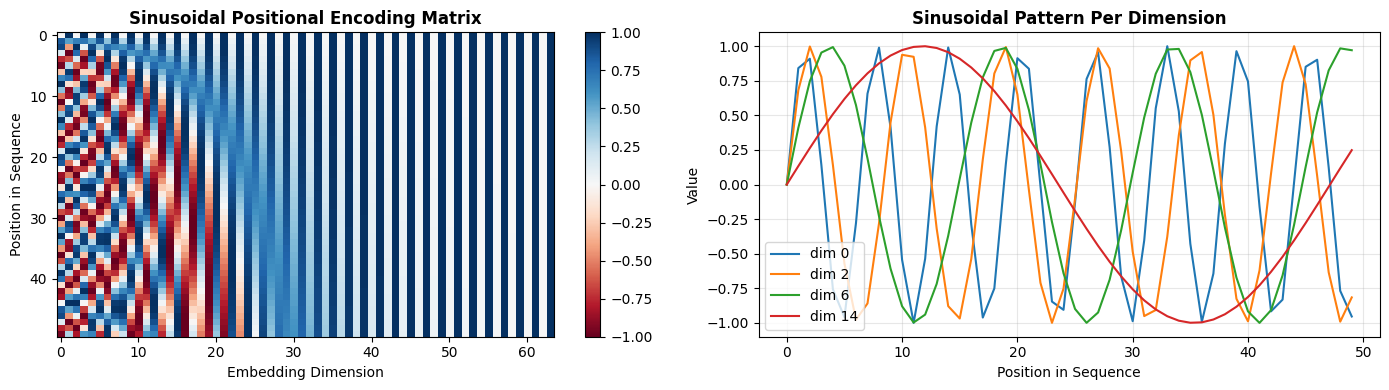


Each position has a unique 'fingerprint' across the dimensions.
Lower dimensions oscillate fast; higher dimensions oscillate slowly.


In [51]:
import math
import matplotlib.pyplot as plt
import numpy as np

def sinusoidal_pos_encoding(max_len, d_model):
    """Build a sinusoidal positional encoding matrix."""
    pe = np.zeros((max_len, d_model))
    pos = np.arange(max_len)[:, np.newaxis]          # shape (max_len, 1)
    i   = np.arange(0, d_model, 2)[np.newaxis, :]    # shape (1, d_model/2)
    div = np.power(10000, i / d_model)
    pe[:, 0::2] = np.sin(pos / div)  # even dims → sin
    pe[:, 1::2] = np.cos(pos / div)  # odd  dims → cos
    return pe

pe = sinusoidal_pos_encoding(max_len=50, d_model=64)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Plot the full matrix as a heatmap
im = axes[0].imshow(pe, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
axes[0].set_title('Sinusoidal Positional Encoding Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Embedding Dimension')
axes[0].set_ylabel('Position in Sequence')
plt.colorbar(im, ax=axes[0])

# Plot a few specific dimensions to show the oscillation
for dim in [0, 2, 6, 14]:
    axes[1].plot(pe[:, dim], label=f'dim {dim}')
axes[1].set_title('Sinusoidal Pattern Per Dimension', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Position in Sequence')
axes[1].set_ylabel('Value')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sinusoidal_pos_encoding.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nEach position has a unique 'fingerprint' across the dimensions.")
print("Lower dimensions oscillate fast; higher dimensions oscillate slowly.")

---
## 🔗 Part 7 — Final Input Embedding: Token + Position

### Putting It All Together

The actual input to a Transformer is the **sum** of token embeddings and positional embeddings:

$$\text{InputEmbedding}[pos] = \text{TokenEmbedding}[\text{token\_id}[pos]] + \text{PosEmbedding}[pos]$$

```
           Sequence position:      0         1         2         3
           Token IDs:            [ 40,      367,     2885,     1464 ]

Token Embeddings:    [t0_vec]  [t1_vec]  [t2_vec]  [t3_vec]    shape: (4, 256)
                        +         +         +         +
Pos   Embeddings:    [p0_vec]  [p1_vec]  [p2_vec]  [p3_vec]    shape: (4, 256)
                     ─────────────────────────────────────────
Input Embeddings:    [e0_vec]  [e1_vec]  [e2_vec]  [e3_vec]    shape: (4, 256)
```

This combined embedding carries both **meaning** (from token embedding) and **order** (from positional embedding).

In [52]:
# ─── Realistic Combined Embedding Pipeline ────────────────────────────────────
VOCAB_SIZE      = 50_257
OUTPUT_DIM      = 256
CONTEXT_LENGTH  = 4      # max sequence length
BATCH_SIZE      = 8

torch.manual_seed(42)

# Create both embedding layers
token_embedding_layer = nn.Embedding(VOCAB_SIZE, OUTPUT_DIM)
pos_embedding_layer   = nn.Embedding(CONTEXT_LENGTH, OUTPUT_DIM)

# Create fake input token IDs  →  shape: (batch_size, context_length)
fake_inputs = torch.randint(0, VOCAB_SIZE, (BATCH_SIZE, CONTEXT_LENGTH))
print(f"Input token IDs shape: {fake_inputs.shape}  ← (batch={BATCH_SIZE}, seq_len={CONTEXT_LENGTH})")

# ① Token embeddings  →  shape: (batch_size, context_length, output_dim)
token_embeddings = token_embedding_layer(fake_inputs)
print(f"Token embeddings shape : {token_embeddings.shape}")

# ② Positional embeddings  →  shape: (context_length, output_dim)
#    torch.arange creates [0, 1, 2, ..., context_length-1]
pos_embeddings = pos_embedding_layer(torch.arange(CONTEXT_LENGTH))
print(f"Pos   embeddings shape : {pos_embeddings.shape}")

# ③ Sum them  →  PyTorch broadcasts (4, 256) across (8, 4, 256)
input_embeddings = token_embeddings + pos_embeddings
print(f"Final input  emb shape : {input_embeddings.shape}  ← ready for the Transformer!")

Input token IDs shape: torch.Size([8, 4])  ← (batch=8, seq_len=4)
Token embeddings shape : torch.Size([8, 4, 256])
Pos   embeddings shape : torch.Size([4, 256])
Final input  emb shape : torch.Size([8, 4, 256])  ← ready for the Transformer!


In [53]:
# ─── Why does addition work? Broadcasting explained ───────────────────────────
print("Broadcasting explanation:")
print(f"  token_embeddings : {token_embeddings.shape}")
print(f"  pos_embeddings   : {pos_embeddings.shape}")
print()
print("  PyTorch sees:")
print("    token:  (8, 4, 256)")
print("    pos  :     (4, 256)  ← no batch dim")
print("  Broadcasting copies pos across all 8 batches automatically.")
print()
print("  Result:  (8, 4, 256)  ← same position vector added to each batch")
print()
print("✓ Every token now has BOTH meaning AND order encoded in one vector.")

Broadcasting explanation:
  token_embeddings : torch.Size([8, 4, 256])
  pos_embeddings   : torch.Size([4, 256])

  PyTorch sees:
    token:  (8, 4, 256)
    pos  :     (4, 256)  ← no batch dim
  Broadcasting copies pos across all 8 batches automatically.

  Result:  (8, 4, 256)  ← same position vector added to each batch

✓ Every token now has BOTH meaning AND order encoded in one vector.


---
## 🔍 Part 8 — Visualizing What Embeddings Look Like

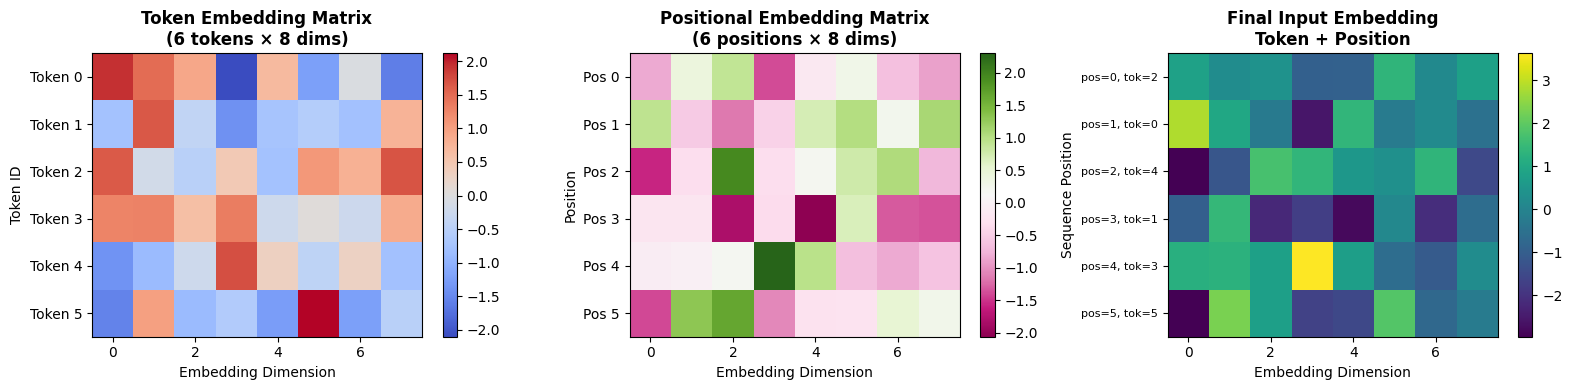

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# ─── Visualize token embeddings for a tiny vocabulary ─────────────────────────
tiny_vocab = 6
tiny_dim   = 8

torch.manual_seed(42)
tiny_embed = nn.Embedding(tiny_vocab, tiny_dim)
weights    = tiny_embed.weight.detach().numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Embedding weight matrix heatmap
im1 = axes[0].imshow(weights, cmap='coolwarm', aspect='auto')
axes[0].set_title('Token Embedding Matrix\n(6 tokens × 8 dims)', fontweight='bold')
axes[0].set_xlabel('Embedding Dimension')
axes[0].set_ylabel('Token ID')
axes[0].set_yticks(range(tiny_vocab))
axes[0].set_yticklabels([f'Token {i}' for i in range(tiny_vocab)])
plt.colorbar(im1, ax=axes[0])

# 2. Positional embedding matrix
tiny_context = 6
torch.manual_seed(7)
tiny_pos = nn.Embedding(tiny_context, tiny_dim)
pos_w    = tiny_pos.weight.detach().numpy()

im2 = axes[1].imshow(pos_w, cmap='PiYG', aspect='auto')
axes[1].set_title('Positional Embedding Matrix\n(6 positions × 8 dims)', fontweight='bold')
axes[1].set_xlabel('Embedding Dimension')
axes[1].set_ylabel('Position')
axes[1].set_yticks(range(tiny_context))
axes[1].set_yticklabels([f'Pos {i}' for i in range(tiny_context)])
plt.colorbar(im2, ax=axes[1])

# 3. Combined (token + pos) embedding for one sequence
seq_ids  = torch.tensor([2, 0, 4, 1, 3, 5])
tok_emb  = tiny_embed(seq_ids).detach().numpy()
pos_idx  = torch.arange(6)
pos_emb  = tiny_pos(pos_idx).detach().numpy()
combined = tok_emb + pos_emb

im3 = axes[2].imshow(combined, cmap='viridis', aspect='auto')
axes[2].set_title('Final Input Embedding\nToken + Position', fontweight='bold')
axes[2].set_xlabel('Embedding Dimension')
axes[2].set_ylabel('Sequence Position')
axes[2].set_yticks(range(6))
axes[2].set_yticklabels([f'pos={i}, tok={seq_ids[i].item()}' for i in range(6)],
                         fontsize=8)
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.savefig('embeddings_visualization.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 📐 Part 9 — Full Pipeline: End-to-End Demo

In [55]:
import torch
import torch.nn as nn
import tiktoken

class TokenAndPositionEmbedding(nn.Module):
    """
    Combined Token + Positional Embedding module.
    This is the input stage of a GPT-style Transformer.

    Args:
        vocab_size     : number of unique tokens
        context_length : maximum sequence length
        embed_dim      : size of each embedding vector
    """
    def __init__(self, vocab_size, context_length, embed_dim):
        super().__init__()
        self.token_embed = nn.Embedding(vocab_size, embed_dim)
        self.pos_embed   = nn.Embedding(context_length, embed_dim)

    def forward(self, token_ids):
        """
        Args:
            token_ids: LongTensor of shape (batch_size, seq_len)
        Returns:
            embeddings: FloatTensor of shape (batch_size, seq_len, embed_dim)
        """
        B, T = token_ids.shape

        # Token embeddings: look up each token's vector
        tok = self.token_embed(token_ids)          # (B, T, D)

        # Positional embeddings: 0, 1, ..., T-1 for each position
        positions = torch.arange(T, device=token_ids.device)
        pos = self.pos_embed(positions)            # (T, D) → broadcast over B

        return tok + pos                           # (B, T, D)


# ─── Configuration ────────────────────────────────────────────────────────────
VOCAB_SIZE      = 50_257  # GPT-2 vocabulary
CONTEXT_LENGTH  = 16      # max tokens in a sequence
EMBED_DIM       = 128     # embedding dimension
BATCH_SIZE      = 4       # number of sequences per batch

# ─── Build and inspect the module ─────────────────────────────────────────────
torch.manual_seed(42)
embed_module = TokenAndPositionEmbedding(VOCAB_SIZE, CONTEXT_LENGTH, EMBED_DIM)

total_params = sum(p.numel() for p in embed_module.parameters())
print("TokenAndPositionEmbedding module:")
print(f"  Token embedding   : {VOCAB_SIZE:,} × {EMBED_DIM} = {VOCAB_SIZE * EMBED_DIM:,} parameters")
print(f"  Pos   embedding   : {CONTEXT_LENGTH} × {EMBED_DIM} = {CONTEXT_LENGTH * EMBED_DIM:,} parameters")
print(f"  Total parameters  : {total_params:,}")

# ─── Forward pass ─────────────────────────────────────────────────────────────
tokenizer  = tiktoken.get_encoding("gpt2")

sentences  = [
    "The quick brown fox jumps",
    "To be or not to be that",
    "Machine learning is very",
    "Language models predict tokens"
]

# Encode each sentence and pad/trim to CONTEXT_LENGTH
def encode_and_pad(text, tokenizer, length):
    ids = tokenizer.encode(text)
    if len(ids) >= length:
        return ids[:length]
    # pad with 0 if shorter
    return ids + [0] * (length - len(ids))

batch_ids = torch.tensor(
    [encode_and_pad(s, tokenizer, CONTEXT_LENGTH) for s in sentences]
)

print(f"\nInput batch shape   : {batch_ids.shape}  ← (batch={BATCH_SIZE}, seq={CONTEXT_LENGTH})")

output = embed_module(batch_ids)
print(f"Output emb  shape   : {output.shape}  ← ready for Transformer layers!")

print(f"\nFirst sentence embedding (first 5 dims of first 4 tokens):")
print(output[0, :4, :5].detach())

TokenAndPositionEmbedding module:
  Token embedding   : 50,257 × 128 = 6,432,896 parameters
  Pos   embedding   : 16 × 128 = 2,048 parameters
  Total parameters  : 6,434,944

Input batch shape   : torch.Size([4, 16])  ← (batch=4, seq=16)
Output emb  shape   : torch.Size([4, 16, 128])  ← ready for Transformer layers!

First sentence embedding (first 5 dims of first 4 tokens):
tensor([[-0.7701,  2.3025, -2.0420,  0.3726,  1.6674],
        [ 1.4826,  0.8145, -2.1049, -0.2022,  1.7694],
        [-1.2922, -1.5934, -2.1996, -1.8397, -2.0950],
        [-1.1670,  0.4018,  0.1532, -0.8987,  0.4576]])


---
## ✅ Summary: The Complete Picture

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                     LLM INPUT PIPELINE                                      │
├─────────────────────────────────────────────────────────────────────────────┤
│                                                                             │
│  Raw Text:  "The cat sat on the mat"                                        │
│       ↓                                                                     │
│  STEP 1 — TOKENIZATION                                                      │
│  Tokens:    ['The', 'cat', 'sat', 'on', 'the', 'mat']                      │
│       ↓                                                                     │
│  STEP 2 — VOCABULARY LOOKUP (encode)                                        │
│  Token IDs: [  464,  3797, 3332, 319,  262, 2603 ]                         │
│       ↓                                                                     │
│  STEP 3 — TOKEN EMBEDDINGS                                                  │
│  Each ID → 256-dim vector  (nn.Embedding: vocab_size × 256)                 │
│  Shape: (6, 256)                                                            │
│       +                                                                     │
│  STEP 4 — POSITIONAL EMBEDDINGS                                             │
│  Position [0,1,2,3,4,5] → 256-dim vector  (nn.Embedding: 6 × 256)          │
│  Shape: (6, 256)                                                            │
│       ↓                                                                     │
│  STEP 5 — ADD THEM                                                          │
│  Input Embeddings = Token Emb + Pos Emb                                     │
│  Shape: (6, 256)  ← carries MEANING + ORDER                                 │
│       ↓                                                                     │
│  → Feed into Transformer Attention Layers                                   │
│                                                                             │
└─────────────────────────────────────────────────────────────────────────────┘
```

### Key Takeaways

| Concept | What It Does | Size (GPT-2) |
|---|---|---|
| **Tokenization** | Splits text into sub-word pieces | — |
| **Vocabulary** | Maps token ↔ integer ID | 50,257 tokens |
| **Token Embedding** | Integer ID → dense vector (meaning) | 50,257 × 768 |
| **Positional Embedding** | Position index → dense vector (order) | 1,024 × 768 |
| **Input Embedding** | Token emb + Pos emb (both meaning + order) | batch × seq × 768 |

### What Happens Next?

The input embeddings flow into **multi-head self-attention** layers, which learn how tokens **relate to each other**. That is the heart of the Transformer — but embeddings are the essential foundation that makes it all work!

---
## 📚 Further Reading

| Resource | What You'll Learn |
|---|---|
| [Attention Is All You Need (2017)](https://arxiv.org/abs/1706.03762) | Original Transformer + sinusoidal embeddings |
| [GPT-2 Paper](https://cdn.openai.com/better-language-models/language_models_are_unsupervised_multitask_learners.pdf) | Learned positional embeddings in GPT |
| [tiktoken](https://github.com/openai/tiktoken) | OpenAI's fast BPE tokenizer |
| [PyTorch nn.Embedding docs](https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html) | Full API reference |
| Sebastian Raschka — *Build a Large Language Model from Scratch* | Textbook this notebook is based on |